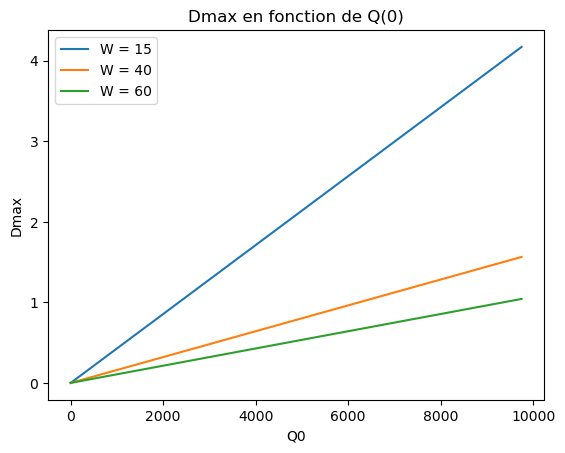

In [1]:
import numpy as np
import matplotlib.pyplot as plt

kabs = 0.25
ke = 0.4
Q0max = int(1*9.75*1000) # 1kg de chocolat noir ingéré (ctype = 5, je suis pas sûre de ça)

def D(t,Q0,W):
  return (kabs*Q0/W*(ke-kabs))*(np.exp(-kabs*t)-np.exp(-ke*t))

def maxD(Q0,W):
  L=[]
  for t in range(0,50):
    L.append(D(t,Q0,W))
  return max(L)

for W in [15,40,60]:
  L_Q0 = [x for x in range(Q0max)]
  L_Dmax = [maxD(y,W) for y in L_Q0]
  plt.plot(L_Q0,L_Dmax, label=f'W = {W}')

plt.title("Dmax en fonction de Q(0)")
plt.xlabel("Q0")
plt.ylabel("Dmax")
plt.legend()
plt.show()

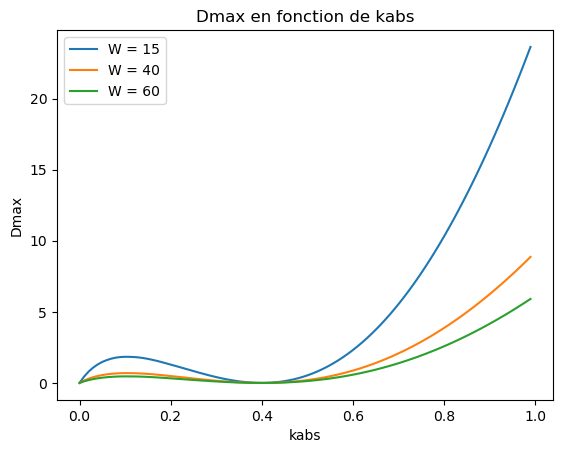

In [2]:
kabsmax = 1
ke = 0.4
Q0 = int(1*200*9.75)

def D(t,kabs,W):
  return (kabs*Q0/W*(ke-kabs))*(np.exp(-kabs*t)-np.exp(-ke*t))

def maxD(kabs,W):
  L=[]
  for t in range(0,50):
    L.append(D(t,kabs,W))
  return max(L)

for W in [15,40,60]:
  L_kabs = [x/100 for x in range(kabsmax*100)]
  L_Dmax = [maxD(y,W) for y in L_kabs]
  plt.plot(L_kabs,L_Dmax, label=f'W = {W}')

plt.title("Dmax en fonction de kabs")
plt.xlabel("kabs")
plt.ylabel("Dmax")
plt.legend()
plt.show()

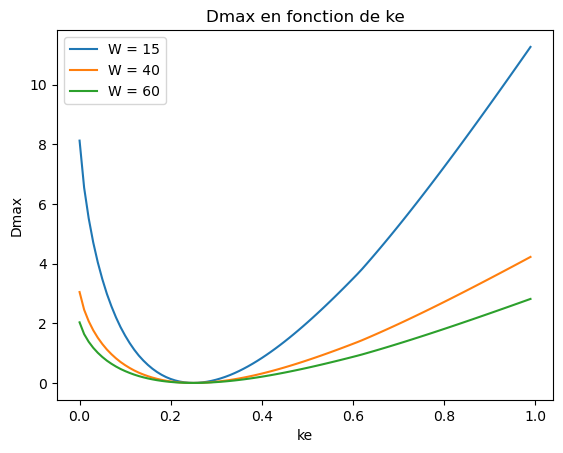

In [3]:
kabs = 0.25
kemax = 1
Q0 = int(1*200*9.75)

def D(t,ke,W):
  return (kabs*Q0/W*(ke-kabs))*(np.exp(-kabs*t)-np.exp(-ke*t))

def maxD(ke,W):
  L=[]
  for t in range(0,50):
    L.append(D(t,ke,W))
  return max(L)

for W in [15,40,60]:
  L_ke = [x/100 for x in range(kemax*100)]
  L_Dmax = [maxD(y,W) for y in L_ke]
  plt.plot(L_kabs,L_Dmax, label=f'W = {W}')

plt.title("Dmax en fonction de ke")
plt.xlabel("ke")
plt.ylabel("Dmax")
plt.legend()
plt.show()

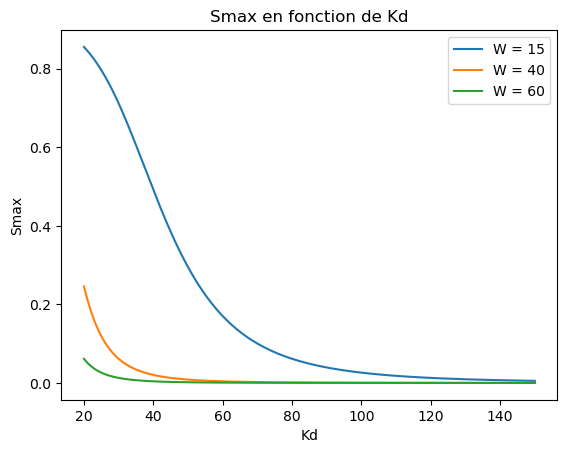

In [4]:
from scipy.integrate import odeint

rho = 0.4
mu_s = 0.026
kabs = 0.25
ke = 0.4
n = 4
L_Kd = [x for x in range(20,151)]
L_W = [15,40,60]

S0=0
t=np.linspace(0,200,1000)
def f(S,t):
  return ((rho*((kabs*Q0/(W*(ke-kabs)))*(np.exp(-kabs*t)-np.exp(-ke*t)))**n)/((((kabs*Q0/(W*(ke-kabs)))*(np.exp(-kabs*t)-np.exp(-ke*t)))**n)+Kd**n))*(1-S)-mu_s*S

for j in range(len(L_W)):
  W = L_W[j]
  L_Dmax = []
  for i in range(len(L_Kd)):
    Kd=L_Kd[i]
    sol=odeint(f,S0,t)
    L_Dmax.append(max(sol))
  plt.plot(L_Kd,L_Dmax, label=f'W = {W}')

plt.title("Smax en fonction de Kd")
plt.xlabel("Kd")
plt.ylabel("Smax")
plt.legend()
plt.show()

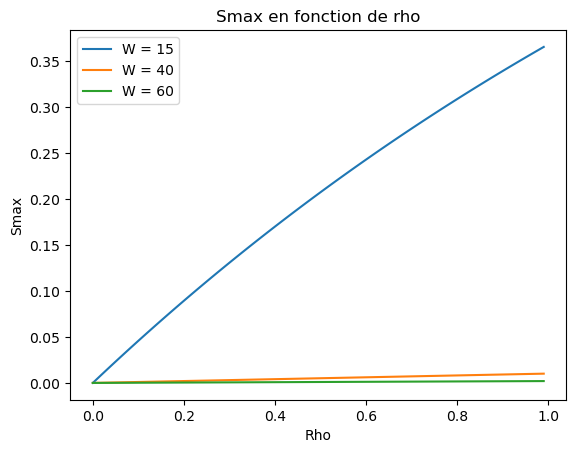

In [5]:
L_rho = [x/100 for x in range(100)]
mu_s = 0.026
kabs = 0.25
ke = 0.4
n = 4
Kd = 60
L_W = [15,40,60]

S0=0
t=np.linspace(0,200,1000)
def f(S,t):
  return ((rho*((kabs*Q0/(W*(ke-kabs)))*(np.exp(-kabs*t)-np.exp(-ke*t)))**n)/((((kabs*Q0/(W*(ke-kabs)))*(np.exp(-kabs*t)-np.exp(-ke*t)))**n)+Kd**n))*(1-S)-mu_s*S

for j in range(len(L_W)):
  W = L_W[j]
  L_Dmax = []
  for i in range(len(L_rho)):
    rho=L_rho[i]
    sol=odeint(f,S0,t)
    L_Dmax.append(max(sol))
  plt.plot(L_rho,L_Dmax, label=f'W = {W}')

plt.title("Smax en fonction de rho")
plt.xlabel("Rho")
plt.ylabel("Smax")
plt.legend()
plt.show()

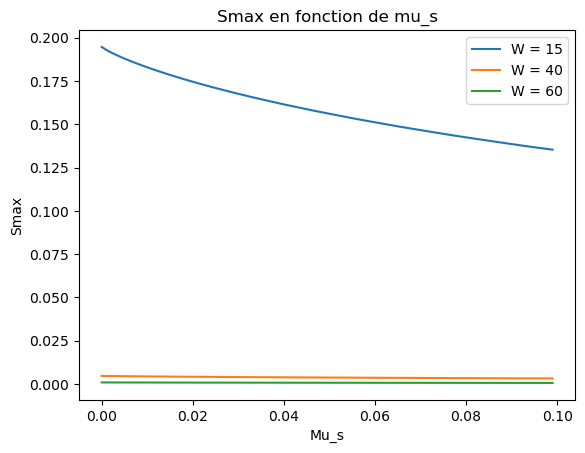

In [6]:
rho = 0.4
L_mu_s = [x/1000 for x in range(100)]
kabs = 0.25
ke = 0.4
n = 4
Kd = 60
L_W = [15,40,60]

S0=0
t=np.linspace(0,200,1000)
def f(S,t):
  return ((rho*((kabs*Q0/(W*(ke-kabs)))*(np.exp(-kabs*t)-np.exp(-ke*t)))**n)/((((kabs*Q0/(W*(ke-kabs)))*(np.exp(-kabs*t)-np.exp(-ke*t)))**n)+Kd**n))*(1-S)-mu_s*S

for j in range(len(L_W)):
  W = L_W[j]
  L_Dmax = []
  for i in range(len(L_mu_s)):
    mu_s = L_mu_s[i]
    sol = odeint(f,S0,t)
    L_Dmax.append(max(sol))
  plt.plot(L_mu_s,L_Dmax, label=f'W = {W}')

plt.title("Smax en fonction de mu_s")
plt.xlabel("Mu_s")
plt.ylabel("Smax")
plt.legend()
plt.show()